In [20]:
%matplotlib widget

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import mplcursors


In [22]:
df = pd.read_excel("perf_llms.xlsx")
df.head()

,model,gpu,task,energy,throughput,response_length,latency,arc,hellaswag,truthfulqa,parameters
0,MetaAI/Llama-7B,A100,chat,335.26,27.47,60.65,1.99,51.11,77.74,34.08,7
1,MetaAI/Llama-7B,V100,chat,335.88,26.08,65.01,2.11,51.11,77.74,34.08,7
2,MetaAI/Llama-7B,V100,chat-concise,354.66,23.93,68.06,2.28,51.11,77.74,34.08,7
3,MetaAI/Llama-7B,A100,chat-concise,369.43,27.65,67.52,2.12,51.11,77.74,34.08,7
4,Neutralzz/BiLLa-7B-SFT,V100,instruct-concise,493.75,30.66,99.96,3.10,27.73,26.04,49.05,7


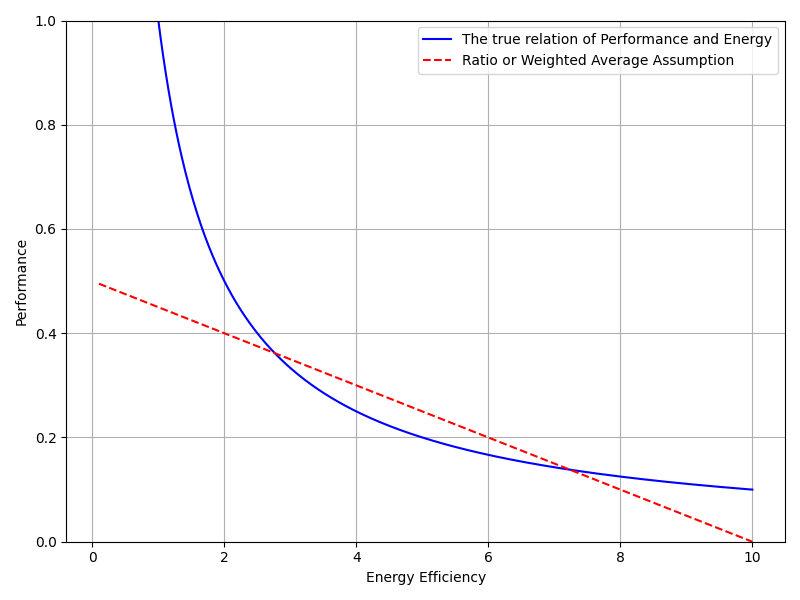

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Generate x values
x = np.linspace(0.1, 10, 500)

# Monotonically decreasing function, e.g., f(x) = 1/x
y_decreasing = 1 / x

# Linear function that intersects the curve, e.g., g(x) = -0.05x + 0.5
y_linear = -0.05 * x + 0.5

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(x, y_decreasing, label='The true relation of Performance and Energy', color='blue')
plt.plot(x, y_linear, label='Ratio or Weighted Average Assumption', color='red', linestyle='--')

# Add labels and legend
plt.xlabel('Energy Efficiency')
plt.ylabel('Performance')
plt.grid(True)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()


In [24]:
def norm_min_max(df: pd.DataFrame, col: str):
    values = df[col]
    return (values - values.min()) / (values.max() - values.min())

In [25]:
gpu = "V100"
task = "chat"
df = df[(df["gpu"] == gpu) & (df["task"] == task)]
df = df.reset_index(drop=True)
df.head()

,model,gpu,task,energy,throughput,response_length,latency,arc,hellaswag,truthfulqa,parameters
0,MetaAI/Llama-7B,V100,chat,335.88,26.08,65.01,2.11,51.11,77.74,34.08,7
1,tatsu-lab/alpaca-7B,V100,chat,727.22,30.31,130.44,4.12,52.65,76.91,39.55,7
2,MetaAI/Llama-13B,V100,chat,772.40,17.27,76.56,3.78,56.31,80.86,39.90,13
3,Neutralzz/BiLLa-7B-SFT,V100,chat,783.93,31.76,160.12,4.94,27.73,26.04,49.05,7
4,H2OAI/H2OGPT-oasst1-7B,V100,chat,1083.43,30.28,216.18,6.90,36.86,61.55,37.94,7


In [26]:
df["average"] = (df["arc"] + df["hellaswag"] + df["truthfulqa"]) / 3
df["avg_norm"] = norm_min_max(df, "average")
df["energy_norm"] = norm_min_max(df, "energy")
df["latency_norm"] = norm_min_max(df, "latency")

In [27]:
df = df.drop(columns=["gpu", "task", "arc", "hellaswag", "truthfulqa", "parameters"])


In [28]:
df.head()

,model,energy,throughput,response_length,latency,average,avg_norm,energy_norm,latency_norm
0,MetaAI/Llama-7B,335.88,26.08,65.01,2.11,54.310000,0.693310,0.000000,0.000000
1,tatsu-lab/alpaca-7B,727.22,30.31,130.44,4.12,56.370000,0.764591,0.143464,0.091823
2,MetaAI/Llama-13B,772.40,17.27,76.56,3.78,59.023333,0.856401,0.160027,0.076291
3,Neutralzz/BiLLa-7B-SFT,783.93,31.76,160.12,4.94,34.273333,0.000000,0.164254,0.129283
4,H2OAI/H2OGPT-oasst1-7B,1083.43,30.28,216.18,6.90,45.450000,0.386736,0.274050,0.218821


In [29]:
df["ene_eff"] = 1 - df["energy_norm"]
df["quickness"] = 1 - df["latency_norm"]
df["perf"] = (df["avg_norm"] + df["quickness"]) / 2

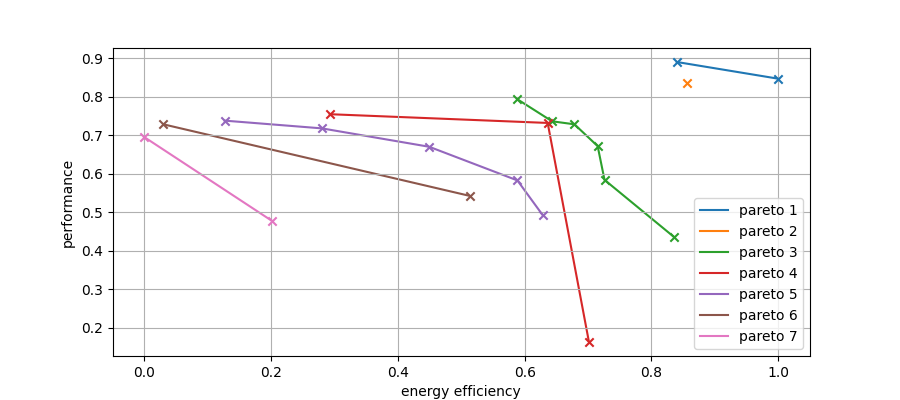

In [30]:
def identify_all_pareto_optimals(x_points, y_points, models):
    all_pareto = []
    while len(x_points) != 0:
        pareto_x = []
        pareto_y = []
        model_names_pareto = []
        non_pareto_x = []
        non_pareto_y = []
        model_names_non_pareto = []
        for i in range(len(x_points)):
            x = x_points[i]
            y = y_points[i]
            mname = models[i]
            is_greater = True
            for j in range(len(x_points)):
                if j == i:
                    continue
                new_x = x_points[j]
                new_y = y_points[j]
                if new_x > x and new_y >= y:
                    is_greater = False
                    break
                if new_y > y and new_x >= x:
                    is_greater = False
                    break
            if is_greater:
                pareto_x.append(x)
                pareto_y.append(y)
                model_names_pareto.append(mname)
            else:
                non_pareto_x.append(x)
                non_pareto_y.append(y)
                model_names_non_pareto.append(mname)
        all_pareto.append((pareto_x, pareto_y, model_names_pareto))
        x_points = non_pareto_x
        y_points = non_pareto_y
        models = model_names_non_pareto
    counter = 1
    scatter_artists = []
    name_lists = []
    fig, ax = plt.subplots(figsize=(9, 4))

    for pareto_x, pareto_y, model_names in all_pareto:
        # sort each triplet by x so your lines stay monotonic
        sorted_triplets = sorted(
            zip(pareto_x, pareto_y, model_names), key=lambda t: t[0]
        )
        xs, ys, names = zip(*sorted_triplets)

        # draw the connecting line
        ax.plot(xs, ys, zorder=1, label=f"pareto {counter}")
        # draw the hoverable markers
        scat = ax.scatter(xs, ys, marker="x", zorder=2)

        scatter_artists.append(scat)
        name_lists.append(names)

        counter += 1

    ax.set_xlabel("energy efficiency")
    ax.set_ylabel("performance")
    ax.grid(True)
    ax.legend(loc="lower right")

    return scatter_artists, name_lists


scatter_artists, name_lists = identify_all_pareto_optimals(
    df["ene_eff"], df["perf"], df["model"]
)
cursor = mplcursors.cursor(scatter_artists, hover=True)


@cursor.connect("add")
def on_add(sel):
    artist = sel.artist  # which PathCollection
    idx = sel.index  # which point index
    # find the matching name-list
    for sc, names in zip(scatter_artists, name_lists):
        if artist is sc:
            model_name = names[idx]
            break

    x, y = artist.get_offsets()[idx]
    other_columns = [
        "energy",
        "response_length",
        "latency",
        "avg_norm",
        "latency_norm",
    ]
    copy_df = df.copy()
    copy_df = copy_df.set_index("model")
    other_stats = " ".join(
        [f"{x}:{copy_df.loc[model_name][x]:.2f}\n\n" for x in other_columns]
    )

    sel.annotation.set_text(
        f"{model_name}\n\n"
        f"Energy Efficiency: {x:.2f}\n\n"
        f"Performance: {y:.2f}\n\n " + other_stats
    )
    bbox = sel.annotation.get_bbox_patch()
    bbox.set_facecolor("blue")
    bbox.set_alpha(0.9)  # make it more opaque
    bbox.set_boxstyle("round,pad=0.5")

    # set the annotation’s text color directly
    sel.annotation.set_color("white")
    # if you want to adjust font size:
    sel.annotation.set_fontsize(8)


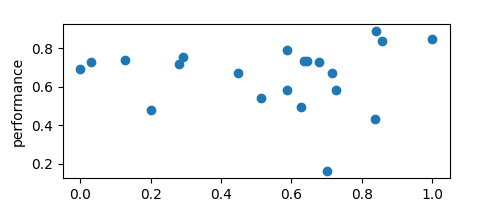

In [31]:
plt.figure(figsize=(5, 2))
plt.scatter(df["ene_eff"], df["perf"])
plt.xlabel("energy efficiency")
plt.ylabel("performance")
plt.show()


In [32]:
import numpy as np

df["perf_scaled"] = (df["perf"] - df["perf"].min()) / (
    df["perf"].max() - df["perf"].min()
)
df["distance"] = ((1 - df["perf_scaled"]) ** 2 + (1 - df["ene_eff"]) ** 2) ** 0.5
df["distance_rank"] = 0

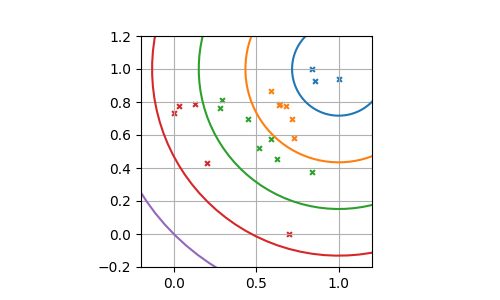

In [33]:
# Circle parameters
center = (1, 1)

plt.figure(figsize=(5, 3))
radiuses = np.linspace(0, np.sqrt(2), 6)

selected_so_far = set()
curr_rank = 5
for r in radiuses:
    if r == 0:
        continue
    # Generate points on the circle
    theta = np.linspace(0, 2 * np.pi, 100)
    x = center[0] + r * np.cos(theta)
    y = center[1] + r * np.sin(theta)
    less_than_r = df[df["distance"] < r].index.to_list()
    new_points = set(less_than_r).difference(selected_so_far)
    selected_so_far.update(less_than_r)
    if new_points:
        df.loc[list(new_points), "distance_rank"] = curr_rank
        curr_rank -= 1
        plt.scatter(
            df.loc[list(new_points), "ene_eff"],
            df.loc[list(new_points), "perf_scaled"],
            marker="x",
            s=12,
        )
    plt.plot(x, y)

plt.gca().set_aspect("equal")  # Equal aspect ratio ensures the circle is round
plt.grid()
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
scatter_points = plt.scatter(df["ene_eff"], df["perf_scaled"], alpha=0)


cursor3 = mplcursors.cursor(scatter_points, hover=True)


@cursor3.connect("add")
def on_add(sel):
    idx = sel.index  # index of the point
    sample = df.iloc[idx]
    annotation_text = f"model name: {sample['model']}\nscaled perf: {sample['perf_scaled']:.2f}\nenergy efficiency: {sample['ene_eff']:.2f}\nrank: {sample['distance_rank']}"
    sel.annotation.set_text(annotation_text)
    bbox = sel.annotation.get_bbox_patch()
    bbox.set_facecolor("blue")
    bbox.set_alpha(0.9)  # make it more opaque
    bbox.set_boxstyle("round,pad=0.5")

    # set the annotation’s text color directly
    sel.annotation.set_color("white")
    # if you want to adjust font size:
    sel.annotation.set_fontsize(8)

 ## Pros
 - it is actaully considering the distance from each point to the most optimal point (this is accurate not approximation)
 - very suitable for labeling
 - distance truly capture model's performance and energy efficiency behavior
 - robust and firm and do not care about outliers also introducing new points does not change its mechanism unlike regression approach
 
 ## Cons
 - distance does not care about the relation between energy efficiency and performance (treat them both linearly or quadratically)
 - all must be scaled into 0-1 to have a fair comparison
 - the circule assumes the points lying on the border of it have same performance (which cannot always be the case)
 - two far points in the same circle still get same label
 - not suitable for ranking (1-2-3-4-...-20) --> because of first problem that I mentioned
 - outliers are somehow revealing whether they are too good or too bad --> in this method it doesn't care but they regression approximation care 
 - it is not relative to other points (it's static, i.e., sometimes we even might end up with no 5 star labels)

In [36]:
# from sklearn.linear_model import LinearRegression
# # from xgboost import XGBRegressor
# import numpy as np

# lr = LinearRegression()
# lr.fit(df["ene_eff"].to_numpy().reshape(-1, 1), df["perf"])
# xgb = XGBRegressor(max_depth=2, learning_rate=0.1, n_estimators=30)
# xgb.fit(df["ene_eff"].to_numpy().reshape(-1, 1), df["perf"])

# # plt.figure(figsize=(5, 2))

# predict_points = np.linspace(0, 1, 25)
# lr_predict = lr.predict(predict_points.reshape(-1, 1))
# xgb_predict = xgb.predict(predict_points.reshape(-1, 1))
# # plt.plot(predict_points, lr_predict, label="lr")
# # plt.plot(predict_points, xgb_predict, label="xgb")
# # plt.scatter(df["ene_eff"], df["perf"], c="red", marker="x", s=16)
# # plt.xlabel("energy efficiency")
# # plt.ylabel("performance")
# # plt.legend()

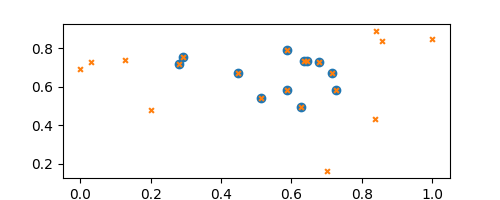

In [39]:
import numpy as np
X = df[["ene_eff", "perf"]].to_numpy()

# 2) compute per-feature mean and std
mean, std = X.mean(axis=0), X.std(axis=0)

# 3) compute absolute z-scores
z = np.abs((X - mean) / std)

# 4) keep only points with both dims within 3σ
mask = (z < 1.1).all(axis=1)
X_clean = X[mask]
plt.figure(figsize=(5, 2))
plt.scatter(X_clean[:, 0], X_clean[:, 1])
plt.scatter(X[:, 0], X[:, 1], marker="x", s=12)

/tmp/ipykernel_1949034/3784090801.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


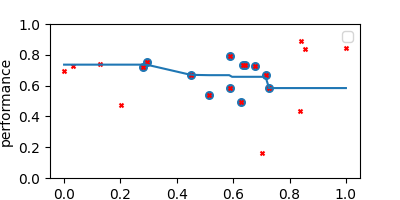

In [40]:
from sklearn.preprocessing import PolynomialFeatures

x_raw, y = X_clean[:, 0], X_clean[:, 1]

# plt.figure(figsize=(4, 2))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degrees = [1, 2, 3]
X_plot = np.linspace(0, 1, 100).reshape(-1, 1)

for degree in degrees:

    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

    # Fit the model
    model.fit(x_raw.reshape(-1, 1), y)

    # Prepare data for plotting the regression curve
    y_plot = model.predict(X_plot)

    # plt.plot(X_plot, y_plot, label=f"linear {degree}")

from sklearn.isotonic import IsotonicRegression

ir = IsotonicRegression(increasing=False, out_of_bounds="clip")
y_pred = ir.fit_transform(x_raw, y)
y_plot = ir.transform(X_plot)

plt.figure(figsize=(4, 2))
plt.plot(X_plot, y_plot)

plt.scatter(X_clean[:, 0], X_clean[:, 1], s=30)
plt.scatter(df["ene_eff"], df["perf"], c="red", marker="x", s=8)
plt.xlabel("energy efficiency")
plt.ylabel("performance")
plt.ylim(0, 1)
plt.legend()

##### The problem with above line is for example it has straight line, which indicates higher energy efficiency with the same performance are in the same category


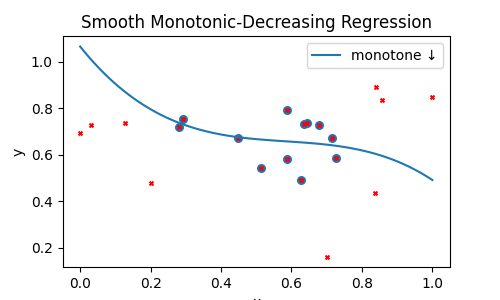

In [55]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt


d = 3 # x^3
b = cp.Variable(d + 1)

# Least-squares objective
x_transformed = np.vander(x_raw, N=d + 1, increasing=True)
objective = cp.Minimize(cp.sum_squares(x_transformed @ b - y))

# Enforce f′(z) ≤ 0 on a grid
z = np.linspace(x_raw.min(), x_raw.max(), 50)
D = np.zeros((len(z), d + 1))
for j, zj in enumerate(z):
    for k in range(1, d + 1):
        D[j, k] = k * zj ** (k - 1)
constraints = [D @ b <= -1e-1]




prob = cp.Problem(objective, constraints)
prob.solve()


# Define breakpoints
# import cvxpy as cp
# import numpy as np

# # Define breakpoints
# n_pieces = 10
# breakpoints = np.linspace(x_raw.min(), x_raw.max(), n_pieces + 1)

# # Variables: values at breakpoints
# f_vals = cp.Variable(n_pieces + 1)

# # Monotone decreasing constraint
# constraints = [f_vals[i+1] <= f_vals[i] - 1e-4 for i in range(n_pieces)]

# # Build interpolation expressions for each data point
# y_pred_list = []
# for xi in x_raw:
#     # Find which piece xi belongs to
#     for j in range(n_pieces):
#         if breakpoints[j] <= xi <= breakpoints[j+1]:
#             # Linear interpolation as cvxpy expression
#             alpha = (xi - breakpoints[j]) / (breakpoints[j+1] - breakpoints[j])
#             y_pred_i = (1-alpha) * f_vals[j] + alpha * f_vals[j+1]
#             y_pred_list.append(y_pred_i)
#             break

# # Stack into cvxpy expression vector
# y_pred = cp.vstack(y_pred_list)

# objective = cp.Minimize(cp.sum_squares(y_pred - y))
# prob = cp.Problem(objective, constraints)
# prob.solve()

# # Extract fitted values
# y_fitted = np.array([y_pred_list[i].value for i in range(len(x_raw))]).flatten()



# below this for plotting

X_plot = np.linspace(0, 1, 100).reshape(-1, 1)
X_grid = np.vander(X_plot.flatten(), N=d + 1, increasing=True)
y_grid = X_grid @ b.value

plt.figure(figsize=(5, 3))
plt.scatter(X_clean[:, 0], X_clean[:, 1], s=30)
plt.scatter(df["ene_eff"], df["perf"], c="red", marker="x", s=8)
plt.plot(X_plot, y_grid, label="monotone ↓")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Smooth Monotonic-Decreasing Regression")
plt.legend()
plt.show()

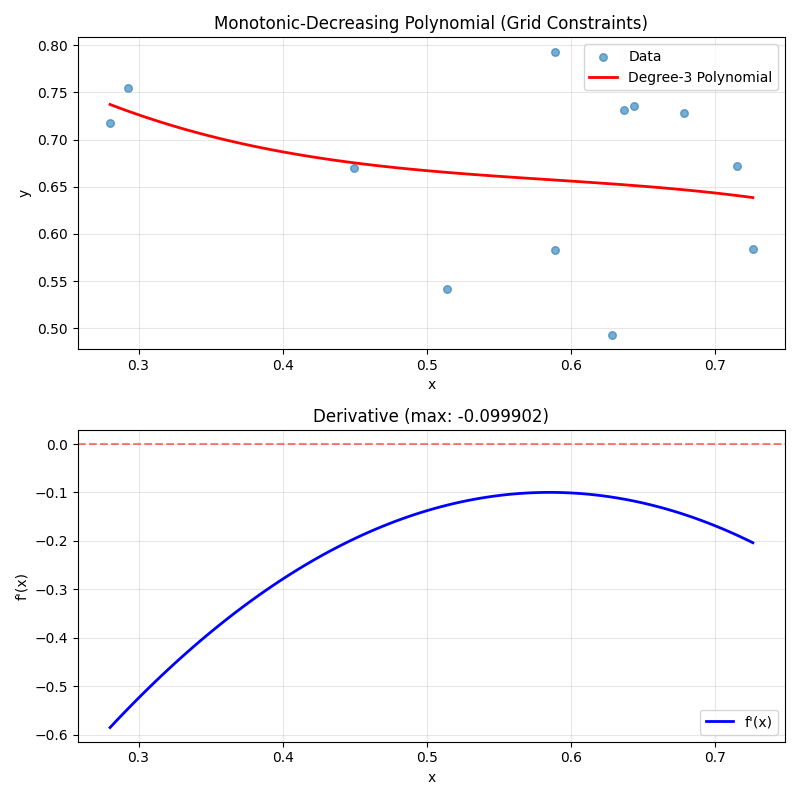

Coefficients: [ 1.06486023 -1.88956245  3.05948323 -1.74341904]


In [ ]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

# Polynomial degree
d = 3
b = cp.Variable(d + 1)

# Transform x data
x_transformed = np.vander(x_raw, N=d + 1, increasing=True)

# Objective
objective = cp.Minimize(cp.sum_squares(x_transformed @ b - y))

# Grid-based derivative constraints (more practical than global)
# Create a dense grid of points
z_grid = np.linspace(x_raw.min(), x_raw.max(), 50)

# Build derivative matrix
D = np.zeros((len(z_grid), d + 1))
for i, zi in enumerate(z_grid):
    for k in range(1, d + 1):
        D[i, k] = k * zi ** (k - 1)

# Constraints: f'(z) < 0 at all grid points
constraints = [D @ b <= -1e-4]

# Add boundary constraints for stronger monotonicity
constraints.append(b[1] <= -1e-6)  # Ensure negative derivative at x=0

prob = cp.Problem(objective, constraints)
prob.solve()

if prob.status == 'optimal':
    # Get fitted values
    y_fitted = (x_transformed @ b.value).flatten()
    
    # For plotting
    X_plot = np.linspace(x_raw.min(), x_raw.max(), 100)
    X_grid = np.vander(X_plot, N=d + 1, increasing=True)
    y_plot = X_grid @ b.value
    
    # Calculate derivative for verification
    D_plot = np.zeros((len(X_plot), d + 1))
    for i, xi in enumerate(X_plot):
        for k in range(1, d + 1):
            D_plot[i, k] = k * xi ** (k - 1)
    y_deriv = D_plot @ b.value
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
    
    ax1.scatter(x_raw, y, s=30, alpha=0.6, label='Data')
    ax1.plot(X_plot, y_plot, 'r-', label=f"Degree-{d} Polynomial", linewidth=2)
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_title("Monotonic-Decreasing Polynomial (Grid Constraints)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(X_plot, y_deriv, 'b-', label="f'(x)", linewidth=2)
    ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax2.set_xlabel("x")
    ax2.set_ylabel("f'(x)")
    ax2.set_title(f"Derivative (max: {np.max(y_deriv):.6f})")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Coefficients: {b.value}")
else:
    print(f"Optimization failed: {prob.status}")

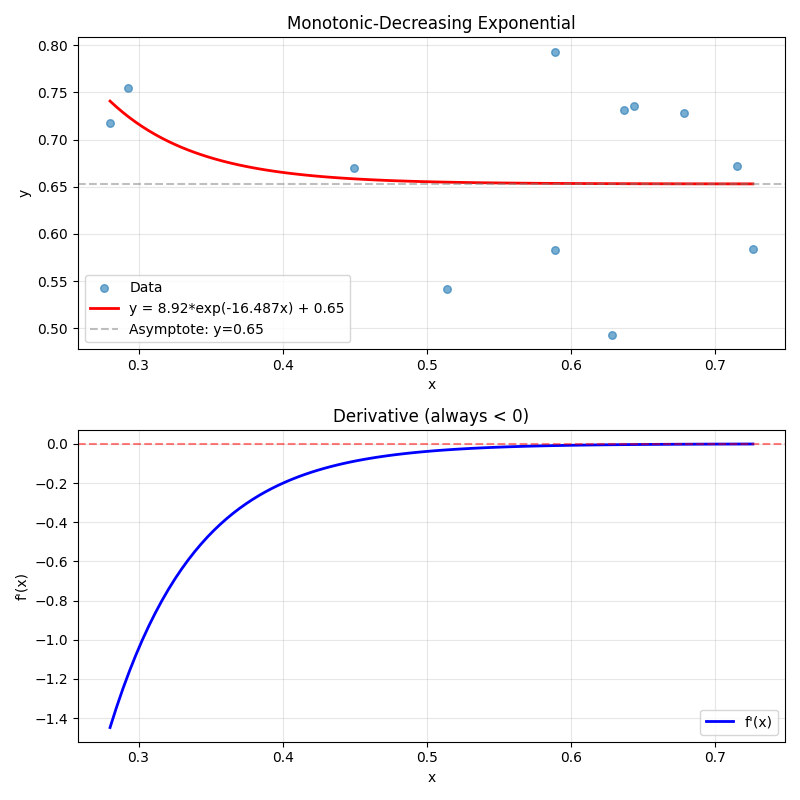

Parameters: a=8.9184, b=16.4872, c=0.6530
R²: 0.1062


In [53]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# For exponential: y = a * exp(-b*x) + c
# This is tricky in CVXPY, so we'll use scipy instead

def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

# Initial guess
y_range = np.max(y) - np.min(y)
p0 = [y_range, 1.0, np.min(y)]

# Bounds to ensure monotone decreasing (b > 0)
bounds = ([1e-4, 1e-6, -np.inf], [np.inf, np.inf, np.max(y)])

try:
    popt, pcov = curve_fit(exp_decay, x_raw, y, p0=p0, bounds=bounds, maxfev=5000)
    a_fit, b_fit, c_fit = popt
    
    # Get fitted values
    y_fitted = exp_decay(x_raw, a_fit, b_fit, c_fit)
    
    # For plotting
    X_plot = np.linspace(x_raw.min(), x_raw.max(), 100)
    y_plot = exp_decay(X_plot, a_fit, b_fit, c_fit)
    
    # Calculate derivative for verification
    y_deriv = -a_fit * b_fit * np.exp(-b_fit * X_plot)
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
    
    ax1.scatter(x_raw, y, s=30, alpha=0.6, label='Data')
    ax1.plot(X_plot, y_plot, 'r-', 
             label=f"y = {a_fit:.2f}*exp(-{b_fit:.3f}x) + {c_fit:.2f}", 
             linewidth=2)
    ax1.axhline(y=c_fit, color='gray', linestyle='--', alpha=0.5, 
                label=f'Asymptote: y={c_fit:.2f}')
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_title("Monotonic-Decreasing Exponential")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(X_plot, y_deriv, 'b-', label="f'(x)", linewidth=2)
    ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax2.set_xlabel("x")
    ax2.set_ylabel("f'(x)")
    ax2.set_title("Derivative (always < 0)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Parameters: a={a_fit:.4f}, b={b_fit:.4f}, c={c_fit:.4f}")
    print(f"R²: {1 - np.sum((y - y_fitted)**2) / np.sum((y - np.mean(y))**2):.4f}")
    
except Exception as e:
    print(f"Exponential fitting failed: {e}")
    print("Try log-linear regression instead...")
    
    # Alternative: Log-linear regression (if all y > 0)
    if np.all(y > 0):
        log_y = np.log(y)
        X_design = np.column_stack([np.ones_like(x_raw), x_raw])
        coeffs = np.linalg.lstsq(X_design, log_y, rcond=None)[0]
        
        a_fit = np.exp(coeffs[0])
        b_fit = -coeffs[1]
        
        if b_fit > 0:  # Ensure decreasing
            y_fitted = a_fit * np.exp(-b_fit * x_raw)
            
            X_plot = np.linspace(x_raw.min(), x_raw.max(), 100)
            y_plot = a_fit * np.exp(-b_fit * X_plot)
            
            plt.figure(figsize=(8, 5))
            plt.scatter(x_raw, y, s=30, alpha=0.6, label='Data')
            plt.plot(X_plot, y_plot, 'r-', 
                     label=f"y = {a_fit:.2f}*exp(-{b_fit:.3f}x)", 
                     linewidth=2)
            plt.xlabel("x")
            plt.ylabel("y")
            plt.title("Log-Linear Regression (No Asymptote)")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()

In [44]:
# (1-alpha) * f_vals[j] + alpha * f_vals[j+1]

In [ ]:
b.value

array([ 1.29233223, -3.34014657,  5.84172995, -3.40571981])

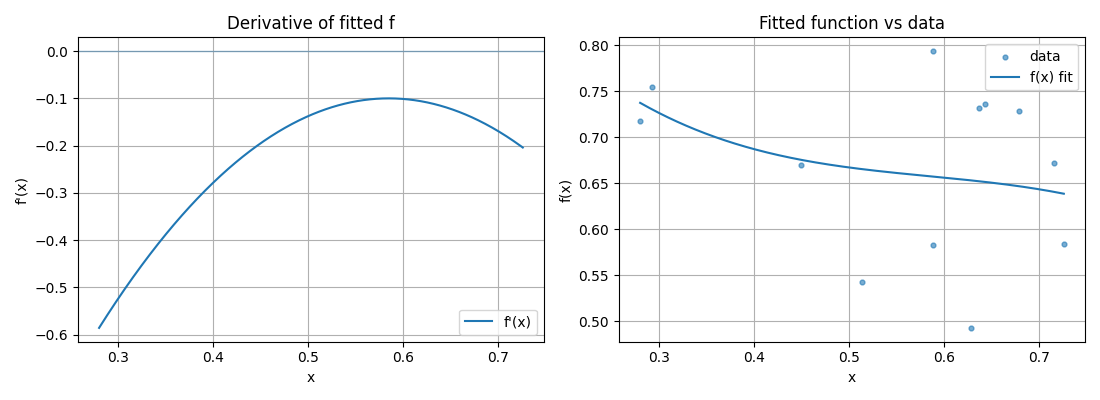

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Grab fitted coefficients
if b.value is None:
    raise RuntimeError(f"Solver status: {prob.status} — no solution coefficients.")
beta = b.value  # shape (d+1,); f(x) = sum_{k=0}^d beta[k] * x^k

# 2) Build derivative coefficients: f'(x) = sum_{k=1}^d k*beta[k] * x^(k-1)
dcoef = np.arange(1, len(beta)) * beta[1:]  # length d

# 3) Helper to evaluate a polynomial given coeffs in increasing-power basis
def eval_poly_increasing(coeffs, x):
    # coeffs = [c0, c1, c2, ...] corresponds to c0 + c1*x + c2*x^2 + ...
    V = np.vander(x, N=len(coeffs), increasing=True)
    return V @ coeffs

# 4) Make a plotting grid
x_plot = np.linspace(x_raw.min(), x_raw.max(), 600)

# 5) Evaluate fitted function and its derivative
y_fit  = eval_poly_increasing(beta, x_plot)
dy_fit = eval_poly_increasing(dcoef, x_plot)

# 6) Plot: derivative (left) and function (right)
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

ax[0].plot(x_plot, dy_fit, label="f'(x)")
ax[0].axhline(0, lw=1, alpha=0.4)
ax[0].set_title("Derivative of fitted f")
ax[0].set_xlabel("x"); ax[0].set_ylabel("f'(x)")
ax[0].grid(True); ax[0].legend()

ax[1].scatter(x_raw, y, s=12, alpha=0.6, label="data")
ax[1].plot(x_plot, y_fit, label="f(x) fit")
ax[1].set_title("Fitted function vs data")
ax[1].set_xlabel("x"); ax[1].set_ylabel("f(x)")
ax[1].grid(True); ax[1].legend()

plt.tight_layout()
plt.show()


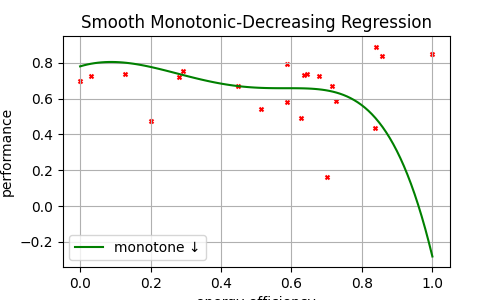

In [ ]:
predicted_y = np.vander(X[:, 0], N=d + 1, increasing=True) @ b.value
X_plot = np.linspace(0, 1, 100).reshape(-1, 1)
X_grid = np.vander(X_plot.flatten(), N=d + 1, increasing=True)
y_grid = X_grid @ b.value
df["predicted_perf"] = np.vander(df["ene_eff"], N=d + 1, increasing=True) @ b.value
df["score"] = df["perf"] / df["predicted_perf"]
min_score, max_score = df["score"].min(), df["score"].max()
five_intervals = (max_score - min_score) / 5
df["regression_rank"] = np.ceil((df["score"] - min_score) / five_intervals)
df.loc[df["regression_rank"] == 0, "regression_rank"] = 1
df["regression_rank"] = df["regression_rank"].astype(int)
# ——— 6. Plot original points and the smooth, descending fit ———
plt.figure(figsize=(5, 3))


# plt.scatter(X[:, 0], predicted_y, s=30)
scatter_points = plt.scatter(df["ene_eff"], df["perf"], c="red", marker="x", s=8)
cursor2 = mplcursors.cursor(scatter_points, hover=True)
plt.plot(X_plot, y_grid, label="monotone ↓", c="green")
plt.xlabel("energy efficiency")
plt.ylabel("performance")
plt.title("Smooth Monotonic-Decreasing Regression")
plt.legend()
plt.grid()


@cursor2.connect("add")
def on_add(sel):
    idx = sel.index  # index of the point
    sample = df.iloc[idx]
    annotation_text = f"model name: {sample['model']}\nactual performance: {sample['perf']:.2f}\nexpected performance: {sample['predicted_perf']:.2f}\nscore: {(sample['score']):.2f}\nregression_rank: {sample['regression_rank']}"
    sel.annotation.set_text(annotation_text)
    bbox = sel.annotation.get_bbox_patch()
    bbox.set_facecolor("blue")
    bbox.set_alpha(0.9)  # make it more opaque
    bbox.set_boxstyle("round,pad=0.5")

    # set the annotation’s text color directly
    sel.annotation.set_color("white")
    # if you want to adjust font size:
    sel.annotation.set_fontsize(8)


plt.show()

 ## Pros
 - it is very suitable for having a quantitiy metric
 - do not need scaling from 0 to 1 (it doesn't change the actual performance)
 
 ## problems 
 - it is not very accurate it depends on the removing outlier points
 - as you see why we should have the first parts of green plots that high 
 - it is not dynamic, for example when we have totaly new measurment and new models, we should see what regression function is the most suitable for it (we cannot have single function for all models)
 - you see that static line betweem 0.3 to 0.7 (this doesn't care about energy efficiency and says all point lying here even with increasing energy efficiency we don't care about them.)
 - not suitable on labeling (1-5)
 - we don't know which `d` to use, the choice of `d` directly impacts on labeling


In [ ]:
min_score, max_score, five_intervals

(np.float64(0.2513082422948818),
 np.float64(2.1820835699331824),
 np.float64(0.3861550655276601))

In [ ]:
min_score + 2 * five_intervals


np.float64(1.023618373350202)

In [ ]:
epsilon = 1e-7
df["ratio_values"] = (df["perf"]) / (df["energy"])
min_ratio, max_ratio = df["ratio_values"].min(), df["ratio_values"].max()
five_intervals = (max_ratio - min_ratio) / 5
df["ratio_rank"] = np.ceil((df["ratio_values"] - min_ratio) / five_intervals)
df.loc[df["ratio_rank"] == 0, "ratio_rank"] = 1
df["ratio_rank"] = df["ratio_rank"].astype(int)
df.drop(columns=["throughput", "response_length",
       'predicted_perf', 'score', "ratio_values", "quickness", "avg_norm", "ene_eff", "latency_norm"])

,model,energy,latency,average,energy_norm,perf,regression_rank,ratio_rank
0,MetaAI/Llama-7B,335.88,2.11,54.310000,0.000000,0.846655,5,5
1,tatsu-lab/alpaca-7B,727.22,4.12,56.370000,0.143464,0.836384,4,3
2,MetaAI/Llama-13B,772.40,3.78,59.023333,0.160027,0.890055,4,3
3,Neutralzz/BiLLa-7B-SFT,783.93,4.94,34.273333,0.164254,0.435359,2,1
4,H2OAI/H2OGPT-oasst1-7B,1083.43,6.90,45.450000,0.274050,0.583957,2,1
5,RWKV/rwkv-raven-7b,1112.95,5.10,48.136667,0.284872,0.671554,3,1
6,LMSys/fastchat-t5-3b-v1.0,1150.40,24.00,43.690000,0.298601,0.162918,1,1
7,FreedomIntelligence/phoenix-inst-chat-7b,1212.85,5.36,51.756667,0.321495,0.728245,3,1
8,BAIR/koala-7b,1308.97,7.93,55.600000,0.356732,0.736036,3,1
9,Salesforce/xgen-7b-8k-inst,1327.98,7.26,54.470000,0.363701,0.731790,3,1


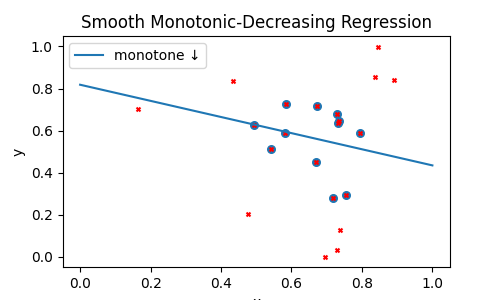

In [ ]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt


# ——— 1. Setup polynomial degree and CVXPY variable ———
d = 1  # e.g. cubic
b = cp.Variable(d + 1)

new_x, new_y = X_clean[:, 1], X_clean[:, 0]
x_transformed = np.vander(new_x, N=d + 1, increasing=True)
objective = cp.Minimize(cp.sum_squares(x_transformed @ b - new_y))
z = np.linspace(new_x.min(), new_x.max(), 50)
D = np.zeros((len(z), d + 1))
for j, zj in enumerate(z):
    for k in range(1, d + 1):
        D[j, k] = k * zj ** (k - 1)
constraints = [D @ b <= 0]


# ——— 4. Solve the QP ———
prob = cp.Problem(objective, constraints)
prob.solve()

# ——— 5. Prepare a fine grid and evaluate the fitted curve ———
X_plot = np.linspace(0, 1, 100).reshape(-1, 1)
X_grid = np.vander(X_plot.flatten(), N=d + 1, increasing=True)
y_grid = X_grid @ b.value


# ——— 6. Plot original points and the smooth, descending fit ———
plt.figure(figsize=(5, 3))
plt.scatter(new_x, new_y, s=30)
plt.scatter(df["perf"], df["ene_eff"], c="red", marker="x", s=8)
plt.plot(X_plot, y_grid, label="monotone ↓")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Smooth Monotonic-Decreasing Regression")
plt.legend()
plt.show()


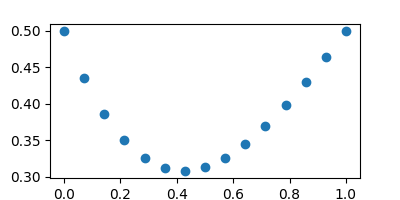

In [ ]:
import numpy as np

plt.figure(figsize=(4, 2))
a = np.linspace(0, 1, 15)
b = a**3
b = b[::-1]
norm_a = (a - a.min()) / (a.max() - a.min())
norm_b = (b - b.min()) / (b.max() - b.min())
plt.scatter(a, (norm_b + norm_a) / 2)
plt.show()

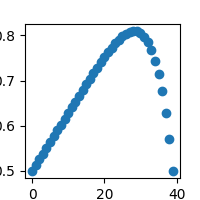

In [ ]:
import numpy as np

plt.figure(figsize=(2, 2))
a = np.arange(40)
b = 500 - a**7 + 2 * a + 3 * a**2 - 5 * a**3
# b = b[::-1]
norm_a = (a - a.min()) / (a.max() - a.min())
norm_b = (b - b.min()) / (b.max() - b.min())
plt.scatter(a, (norm_b + norm_a) / 2)
plt.show()

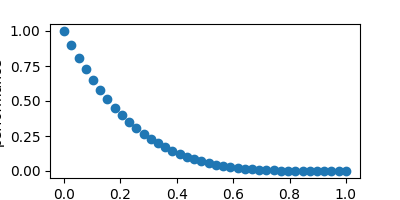

In [ ]:
import numpy as np

plt.figure(figsize=(4, 2))
a = np.arange(40)
b = a**4 - 3 * a**2 + 2 * a
b = b[::-1]
norm_a = (a - a.min()) / (a.max() - a.min())
norm_b = (b - b.min()) / (b.max() - b.min())
plt.scatter(norm_a, norm_b)
plt.xlabel("energy efficiency")
plt.ylabel("performance")
plt.show()

In [ ]:
a = np.arange(8)
b = a**3
b = b[::-1]
norm_a = (a - a.min()) / (a.max() - a.min())
norm_b = (b - b.min()) / (b.max() - b.min())
norm_a, norm_b

(array([0.        , 0.14285714, 0.28571429, 0.42857143, 0.57142857,
        0.71428571, 0.85714286, 1.        ]),
 array([1.        , 0.62973761, 0.36443149, 0.18658892, 0.0787172 ,
        0.02332362, 0.00291545, 0.        ]))

In [ ]:
b

array([343, 216, 125,  64,  27,   8,   1,   0])

In [ ]:
b.max() - b.min()


np.int64(343)

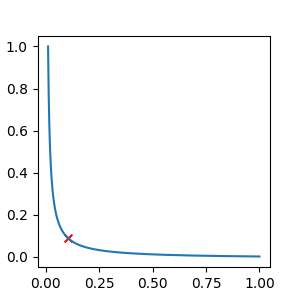

In [ ]:
import numpy as np

x = np.linspace(0.01, 1, 1000)
y = 1 / x
y = (y - y.min()) / (y.max() - y.min())

plt.figure(figsize=(3, 3))
plt.plot(x, y)
plt.scatter(x[92], y[92], marker="x", c="red", s=32)


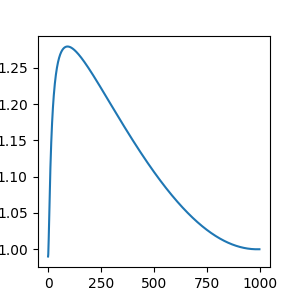

In [ ]:
max_point_x, max_point_y = 1, 1


def find_distance(x_points, y_points):

    distances = ((x_points - max_point_x) ** 2 + (y_points - max_point_y) ** 2) ** 0.5

    return distances


distances = find_distance(x, y)


plt.figure(figsize=(3, 3))


plt.plot(distances)

In [ ]:
distances.argmax()


np.int64(92)

In [ ]:
(x[250] - 1) ** 2 + (x[250] - 1)

np.float64(-0.19131384627871117)